In [28]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , mean_squared_error , r2_score
from torch.utils.data import DataLoader, TensorDataset

# Question 1: Feedforward Neural Network for Regression

Implement a Feedforward Neural Network (FNN) for the Graduate Admission Dataset.

Architecture:
- Hidden Layer 1: 7 neurons (ReLU)
- Hidden Layer 2: 7 neurons (ReLU)
- Output Layer: 1 neuron (Regression)

### Load Dataset and Preprocessing

In [2]:
df = pd.read_csv('Graduate Admission Dataset.csv')

In [3]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

There is no null or missing value in the dataset so it is preprocessed only

In [4]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [5]:
X = df.drop("Chance of Admit ", axis=1).values
y = df["Chance of Admit "].values.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_val = torch.FloatTensor(y_val)
y_test = torch.FloatTensor(y_test)

### a) Build the FNN with two hidden layers, each having 7 neurons and ReLU activationfunction 

In [6]:
class FNN_Regression(nn.Module):
    def __init__(self, input_size):
        super(FNN_Regression, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 7),
            nn.ReLU(),
            nn.Linear(7, 7),
            nn.ReLU(),
            nn.Linear(7, 1)
        )
        
    def forward(self, x):
        return self.model(x)

model = FNN_Regression(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### b) Train the model

In [7]:
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())

### c) Visualise and compare the training and validation loss across epochs 

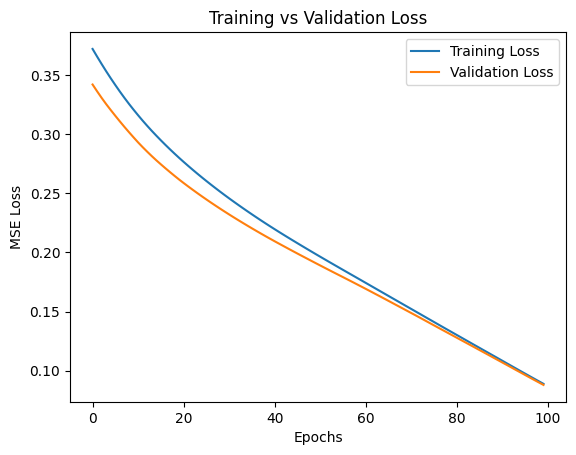

In [8]:
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### d) Evaluate the model on the test set and report test loss along with relevant regression metrics such as R-squared

In [9]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    r2 = r2_score(y_test.numpy(), predictions.numpy())

print("Test Loss:", test_loss.item())
print("R2 Score:", r2)

Test Loss: 0.08313031494617462
R2 Score: -2.9669618606567383


## Train, Validation and Test Sets in Deep Learning

In deep learning, the dataset is typically divided into three parts:

### 1. Training Set
The training set is used to:
- Compute loss
- Perform backpropagation
- Update model weights

This is the only dataset used for learning model parameters.

---

### 2. Validation Set
The validation set is used during training to:
- Monitor model performance
- Detect overfitting
- Tune hyperparameters (learning rate, number of layers, dropout, etc.)

The model **does not update its weights** using validation data.

If training loss decreases while validation loss increases, it indicates overfitting.

---

### Why Not Use k-Fold Cross-Validation in Deep Learning?

In traditional machine learning, k-fold cross-validation is commonly used because:
- Models are relatively fast to train
- Datasets are usually smaller
- It provides a robust estimate of performance

However, in deep learning:

- Training neural networks is computationally expensive
- Models require many epochs
- Running k-fold would require training the model k times
- This significantly increases training time

Therefore, k-fold cross-validation is generally avoided in deep learning.

---

### When Should k-Fold Be Used?

k-fold cross-validation is useful when:
- The dataset is small
- The model is simple and fast to train
- A more stable performance estimate is required

It is commonly used in classical machine learning algorithms such as:
- Logistic Regression
- SVM
- Decision Trees

---

### What Is Used in Deep Learning Instead?

In deep learning, we typically use **Hold-Out Validation**, which means:

1. Split the dataset into:
   - Training set
   - Validation set
   - Test set
2. Train the model on the training set
3. Evaluate performance on the validation set during training
4. Select the best model based on validation performance
5. Finally evaluate once on the test set

This approach balances computational efficiency and reliable model evaluation.

---

### 3. Test Set
The test set is used:
- Only after training is complete
- To evaluate final model performance on unseen data

It provides an unbiased estimate of real-world performance.

The test set must never be used for training or hyperparameter tuning.

---

### Summary

- Training set → Learn parameters  
- Validation set → Tune hyperparameters & monitor generalization  
- Test set → Final unbiased evaluation  
- k-fold → Used mainly in classical ML, rarely in deep learning due to high computational cost  

# Question 2: Feedforward Neural Network for Heart Disease Dataset

Architecture:
- Dense layer with 8 neurons (ReLU)
- Dense layer with 4 neurons (ReLU)
- Output layer with 1 neuron (Sigmoid)

We train the model:
1. Without dropout
2. With dropout (50% and 30%)

We compare training and validation performance.

In [10]:
df = pd.read_csv("heart disease.csv")

X = df.drop("target", axis=1).values
y = df["target"].values.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_val = torch.FloatTensor(y_val)
y_test = torch.FloatTensor(y_test)

###  Build the FNN using the following architecture:
• ReLU-activated dense layer with 8 neurons
• ReLU-activated dense layer with 4 neurons
• Sigmoid-activated output layer with 1 neuron

In [11]:
class FNN_Heart(nn.Module):
    def __init__(self, input_size):
        super(FNN_Heart, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

### Modify the network architecture by introducing dropout layers:
• 50% dropout in the first hidden layer
• 30% dropout in the second hidden layer

In [12]:
class FNN_Heart_Dropout(nn.Module):
    def __init__(self, input_size):
        super(FNN_Heart_Dropout, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

### b) TRAINING FUNCTION

In [13]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=100):
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    val_losses = []
    train_acc = []
    val_acc = []
    
    for epoch in range(epochs):
        
        # Training
        model.train()
        optimizer.zero_grad()
        
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        pred = (output > 0.5).float()
        acc = (pred == y_train).float().mean()
        train_acc.append(acc.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            val_losses.append(val_loss.item())
            
            val_pred = (val_output > 0.5).float()
            val_accuracy = (val_pred == y_val).float().mean()
            val_acc.append(val_accuracy.item())
    
    return train_losses, val_losses, train_acc, val_acc

In [14]:
# Without Dropout
model1 = FNN_Heart(X_train.shape[1])
train_loss1, val_loss1, train_acc1, val_acc1 = train_model(
    model1, X_train, y_train, X_val, y_val
)

# With Dropout
model2 = FNN_Heart_Dropout(X_train.shape[1])
train_loss2, val_loss2, train_acc2, val_acc2 = train_model(
    model2, X_train, y_train, X_val, y_val
)

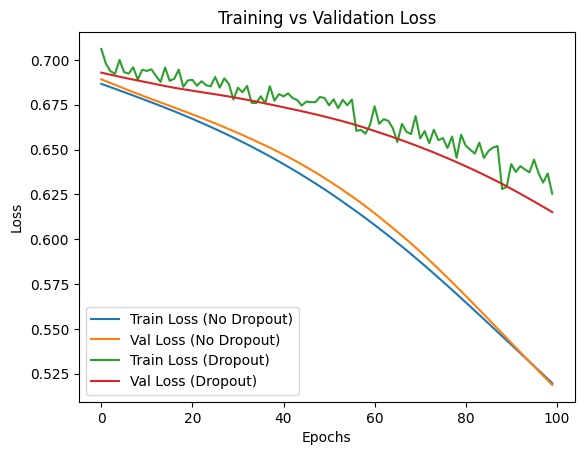

In [15]:
plt.figure()
plt.plot(train_loss1, label="Train Loss (No Dropout)")
plt.plot(val_loss1, label="Val Loss (No Dropout)")
plt.plot(train_loss2, label="Train Loss (Dropout)")
plt.plot(val_loss2, label="Val Loss (Dropout)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

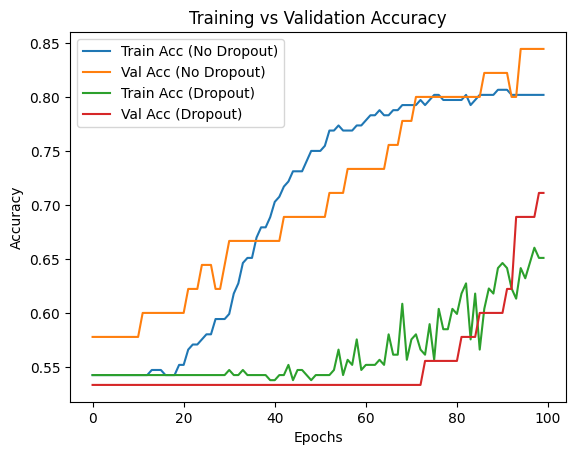

In [16]:
plt.figure()
plt.plot(train_acc1, label="Train Acc (No Dropout)")
plt.plot(val_acc1, label="Val Acc (No Dropout)")
plt.plot(train_acc2, label="Train Acc (Dropout)")
plt.plot(val_acc2, label="Val Acc (Dropout)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [17]:
model2.eval()
with torch.no_grad():
    test_output = model2(X_test)
    test_pred = (test_output > 0.5).float()
    test_accuracy = (test_pred == y_test).float().mean()

print("Test Accuracy (Best Model):", test_accuracy.item())

Test Accuracy (Best Model): 0.6739130616188049


In [18]:
model1.eval()
with torch.no_grad():
    test_output = model1(X_test)
    test_pred = (test_output > 0.5).float()
    test_accuracy = (test_pred == y_test).float().mean()

print("Test Accuracy (Best Model):", test_accuracy.item())

Test Accuracy (Best Model): 0.760869562625885


### Analyze how dropout affects model generalization and overfitting behavior

### Analysis of Dropout Effect

In this experiment, the model without dropout achieved higher validation and test accuracy compared to the model with dropout.

This suggests that the original model was not significantly overfitting the training data.

Since the architecture is relatively small (8 → 4 → 1), introducing dropout reduced the effective capacity of the network and led to slight underfitting.

Dropout is more beneficial in deeper networks with a large number of parameters, where overfitting is more likely.

In this case, the simpler model without dropout generalizes better for this dataset.

# 3) Implement a Feedforward Neural Network (FNN) using the Modified Fashion MNIST
Dataset. (5)
a) Experiment with the following hyperparameters to optimize the FNN:
• Number of hidden layers (eg: 1,2)
• Number of neurons per layer(eg : [128], [128,64])
• Number of epochs (eg: 10, 20)
• Learning rate (eg : 0.001, 0.0005)
• Dropout rate (eg : 0.1, 0.2)
• Batch size (eg: 16, 32)
• Optimizer (eg : Adam, RMSprop)
b) Train the model and identify the best configuration (3.5)
c) Visualize and compare:
• Training and validation loss (0.5)
• Training and validation accuracy (0.5)
d) Evaluate the model on the test set and report the test accuracy 

### Load Dataset and Preprocessing

In [19]:
df = pd.read_csv("Modified Fashion MNIST (1).csv")

X = df.drop("label", axis=1).values
y = df["label"].values  # Do NOT reshape for CrossEntropyLoss

# Normalize pixel values
X = X / 255.0

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)
y_test = torch.LongTensor(y_test)

### Flexible Model

In [30]:
class FNN_Fashion(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout):
        super(FNN_Fashion, self).__init__()
        
        layers = []
        prev = input_size
        
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        
        layers.append(nn.Linear(prev, 10))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

### Hyperparameter Grid

In [31]:
hidden_layer_options = [[128],[128, 64]]
learning_rates = [0.001, 0.0005]
dropout_rates = [0.1, 0.2]
epochs_options = [10, 20]
batch_sizes = [16, 32]
optimizers_list = ["adam", "rmsprop"]

### Training Function (Mini-Batch)

In [32]:
def train_model(model, train_loader, val_loader, optimizer, epochs):
    
    criterion = nn.CrossEntropyLoss()
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        
        # ---- Training ----
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for xb, yb in train_loader:
            
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        
        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)
        
        # ---- Validation ----
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)
        
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)
    
    return train_losses, val_losses, train_accs, val_accs

### Grid Search Loop

In [33]:
results = []

for hidden_layers in hidden_layer_options:
    for lr in learning_rates:
        for dropout in dropout_rates:
            for epochs in epochs_options:
                for batch_size in batch_sizes:
                    for opt_name in optimizers_list:
                        
                        train_dataset = TensorDataset(X_train, y_train)
                        val_dataset = TensorDataset(X_val, y_val)
                        
                        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                        val_loader = DataLoader(val_dataset, batch_size=batch_size)
                        
                        model = FNN_Fashion(
                            input_size=X_train.shape[1],
                            hidden_layers=hidden_layers,
                            dropout=dropout
                        )
                        
                        if opt_name == "adam":
                            optimizer = optim.Adam(model.parameters(), lr=lr)
                        else:
                            optimizer = optim.RMSprop(model.parameters(), lr=lr)
                        
                        train_loss, val_loss, train_acc, val_acc = train_model(
                            model, train_loader, val_loader, optimizer, epochs
                        )
                        
                        best_val_acc = max(val_acc)
                        
                        results.append({
                            "hidden_layers": hidden_layers,
                            "lr": lr,
                            "dropout": dropout,
                            "epochs": epochs,
                            "batch_size": batch_size,
                            "optimizer": opt_name,
                            "model": model,
                            "train_loss": train_loss,
                            "val_loss": val_loss,
                            "train_acc": train_acc,
                            "val_acc": val_acc,
                            "best_val_acc": best_val_acc
                        })
                        
                        print("Done:", hidden_layers, lr, dropout, epochs, batch_size, opt_name)

Done: [128] 0.001 0.1 10 16 adam
Done: [128] 0.001 0.1 10 16 rmsprop
Done: [128] 0.001 0.1 10 32 adam
Done: [128] 0.001 0.1 10 32 rmsprop
Done: [128] 0.001 0.1 20 16 adam
Done: [128] 0.001 0.1 20 16 rmsprop
Done: [128] 0.001 0.1 20 32 adam
Done: [128] 0.001 0.1 20 32 rmsprop
Done: [128] 0.001 0.2 10 16 adam
Done: [128] 0.001 0.2 10 16 rmsprop
Done: [128] 0.001 0.2 10 32 adam
Done: [128] 0.001 0.2 10 32 rmsprop
Done: [128] 0.001 0.2 20 16 adam
Done: [128] 0.001 0.2 20 16 rmsprop
Done: [128] 0.001 0.2 20 32 adam
Done: [128] 0.001 0.2 20 32 rmsprop
Done: [128] 0.0005 0.1 10 16 adam
Done: [128] 0.0005 0.1 10 16 rmsprop
Done: [128] 0.0005 0.1 10 32 adam
Done: [128] 0.0005 0.1 10 32 rmsprop
Done: [128] 0.0005 0.1 20 16 adam
Done: [128] 0.0005 0.1 20 16 rmsprop
Done: [128] 0.0005 0.1 20 32 adam
Done: [128] 0.0005 0.1 20 32 rmsprop
Done: [128] 0.0005 0.2 10 16 adam
Done: [128] 0.0005 0.2 10 16 rmsprop
Done: [128] 0.0005 0.2 10 32 adam
Done: [128] 0.0005 0.2 10 32 rmsprop
Done: [128] 0.0005 0.2

### Select Best Configuration

In [35]:
best_result = max(results, key=lambda x: x["best_val_acc"])

print("Best Configuration:")
print("Hidden Layers:", best_result["hidden_layers"])
print("Learning Rate:", best_result["lr"])
print("Dropout:", best_result["dropout"])
print("Epochs:", best_result["epochs"])
print("Batch Size:", best_result["batch_size"])
print("Optimizer:", best_result["optimizer"])
print("Best Validation Accuracy:", best_result["best_val_acc"])

Best Configuration:
Hidden Layers: [128, 64]
Learning Rate: 0.0005
Dropout: 0.1
Epochs: 20
Batch Size: 16
Optimizer: adam
Best Validation Accuracy: 0.8477777777777777


### Plot Best Curves

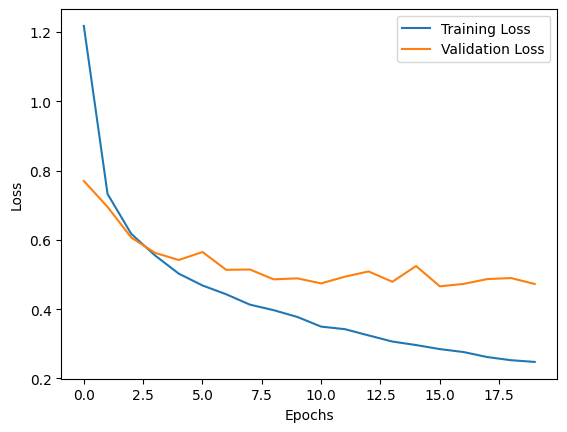

In [36]:
plt.figure()
plt.plot(best_result["train_loss"], label="Training Loss")
plt.plot(best_result["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

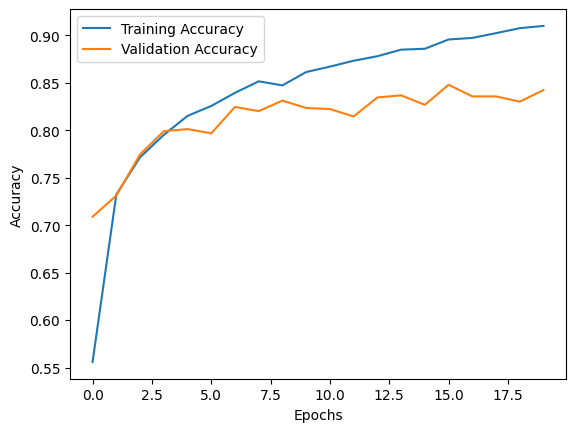

In [37]:
plt.figure()
plt.plot(best_result["train_acc"], label="Training Accuracy")
plt.plot(best_result["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Final Test Accuracy

In [38]:
best_model = best_result["model"]

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32)

best_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = best_model(xb)
        _, preds = torch.max(outputs, 1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print("Final Test Accuracy:", correct / total)

Final Test Accuracy: 0.8522222222222222
